# Decision Tree on HR_data.csv (based on exercise6-decision_tree.ipynb, Part 4)

This notebook reuses the same settings and code structure from **Part 4: Decision trees** of
`exercise6-decision_tree.ipynb` (the Iris decision tree exercise), but applies them to `HR_data.csv`
instead of the Iris dataset.

We predict whether a person is **frustrated** (`Frustrated_binary = 1`) or **not frustrated**
(`Frustrated_binary = 0`), based on 5 heart-rate (HR) features — `HR_Mean`, `HR_Median`, `HR_std`,
`HR_Max`, `HR_AUC` — plus `Phase` and `Round` (one-hot encoded), using:

- `DecisionTreeClassifier` with `criterion="gini"` — same settings as Task 4.2.
- A sweep over `max_depth` (Task 4.3/4.4) to **select `max_depth` before** fitting the final model,
  instead of fixing it at 15.

**Feature set:** `HR_data.csv` has 6 HR features (`HR_Mean`, `HR_Median`, `HR_std`, `HR_Min`,
`HR_Max`, `HR_AUC`). Based on the correlation analysis in `feature_correlation_analysis.ipynb`, we
use 5 of these — `HR_Mean`, `HR_Median`, `HR_std`, `HR_Max`, `HR_AUC` — and drop `HR_Min`. In
addition, we one-hot encode `Phase` (3 levels) and `Round` (4 levels) and include them as features,
so the model can also learn from which phase/round a measurement was taken. All three model
notebooks are trained on this same fixed feature set: the 5 HR features plus one-hot encoded
`Phase`/`Round`. No automatic feature selection is applied — every fold's tree can split on any of
these columns.

**Avoiding data leakage & nested LOSO:** `HR_data.csv` contains 14 individuals, each with 12 rows
(4 rounds x 3 phases). A plain random row-wise split can put rows from the *same* individual in
both the training and test set, inflating the test accuracy. With only 14 individuals, a single
80/20 hold-out split would also only contain 2-3 test individuals — far too noisy an estimate. We
therefore use **nested Leave-One-Subject-Out (LOSO) cross-validation**:

- **Outer loop** (`LeaveOneGroupOut`, grouped by `Individual`): one individual at a time is held out
  as the test set (12 rows).
- **Inner loop** (`GroupKFold` on the remaining 13 individuals): selects `max_depth` (Task 4.3/4.4)
  *without ever using the outer fold's held-out individual*.
- The tree (with the selected `max_depth`) is refit on all 13 training individuals and evaluated
  **once** on the held-out individual.

This is repeated 14 times, so every observation gets exactly one out-of-fold prediction, giving an
honest estimate of how the model generalizes to a new person.

**Avoiding overfitting:** With a fixed `max_depth=15`, the tree reached 100% training accuracy
(clear overfitting) while the cross-validation curve showed test error increasing with depth. We
therefore select `max_depth` via cross-validation **inside each outer LOSO fold**, rather than
fixing it arbitrarily.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Plotting style
sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

# Random seed
seed = 123
np.random.seed(seed)


## Task 4.1 equivalent: Load HR_data.csv and define X and y

`Frustrated` is rated on a scale from 0-8. We turn it into a binary label `Frustrated_binary`
(0 = not frustrated, 1 = frustrated) using a threshold, same as in the other notebooks for this task.

As features `X`, we use 5 heart-rate (HR) features — `HR_Mean`, `HR_Median`, `HR_std`, `HR_Max`,
`HR_AUC` — plus one-hot encoded `Phase` and `Round` (see the feature-set note above). `y` is the
binary frustration label. `groups` holds the `Individual` id for each row, used for the
group-aware splits below.


In [2]:
# Load the HR dataset
df = pd.read_csv("HR_data.csv", index_col=0)

# Turn Frustrated (0-8) into a binary label
threshold = 3
df["Frustrated_binary"] = (df["Frustrated"] >= threshold).astype(int)

# 5 HR features (HR_Min excluded), plus one-hot encoded Phase and Round
hr_feature_cols = ["HR_Mean", "HR_Median", "HR_std", "HR_Max", "HR_AUC"]

X = pd.get_dummies(df[hr_feature_cols + ["Phase", "Round"]], columns=["Phase", "Round"], drop_first=True)
y = df["Frustrated_binary"]
groups = df["Individual"].to_numpy()
feature_cols = list(X.columns)

print(f"X.shape: {X.shape}")
print(f"y.shape: {y.shape}")
print(f"Feature columns: {feature_cols}")
print(f"Number of individuals: {len(np.unique(groups))}")
y.value_counts()


X.shape: (168, 10)
y.shape: (168,)
Feature columns: ['HR_Mean', 'HR_Median', 'HR_std', 'HR_Max', 'HR_AUC', 'Phase_phase2', 'Phase_phase3', 'Round_round_2', 'Round_round_3', 'Round_round_4']
Number of individuals: 14


Frustrated_binary
0    105
1     63
Name: count, dtype: int64

### Features used in this model

This decision tree is trained on **all 10 columns** of `X` printed above — no feature selection is
applied, every fold's tree can split on any of these:

- `HR_Mean`, `HR_Median`, `HR_std`, `HR_Max`, `HR_AUC` (raw, not per-individual normalized for this model).
- `Phase_phase2`, `Phase_phase3` — one-hot encoding of `Phase` (`phase1` is the dropped/reference level).
- `Round_round_2`, `Round_round_3`, `Round_round_4` — one-hot encoding of `Round` (`round_1` is the
  dropped/reference level).

`HR_Min` is **not** used as a feature. `Individual`/`groups` is **not** a feature either — it is
only used to define the LOSO train/test splits so that no individual appears in both the training
and test set of a fold.

## Nested LOSO cross-validation: select `max_depth` and evaluate

For each of the 14 outer LOSO folds (one held-out individual at a time):

1. **Inner CV** (`GridSearchCV` with `GroupKFold`, grouped by `Individual`, on the remaining 13
   individuals): for a `DecisionTreeClassifier` (`criterion="gini"`), search over
   `max_depth = 1, ..., 8` (Task 4.3/4.4), scoring by balanced accuracy.
2. Pick `best_max_depth` as the value with the highest mean inner-CV balanced accuracy.
3. Refit the tree with the selected `max_depth` on all 13 training individuals, and predict
   on the held-out individual's 12 rows.

This gives every observation exactly one out-of-fold prediction (`oof_pred`), made by a model that
never saw that individual during training or `max_depth` selection.


In [3]:
max_depth_grid = list(range(1, 9))
inner_K = 4  # inner GroupKFold folds over the 13 training individuals

pipeline = Pipeline([
    ("clf", DecisionTreeClassifier(criterion="gini", random_state=seed)),
])

param_grid = {
    "clf__max_depth": max_depth_grid,
}

X_np = X.to_numpy()
y_np = y.to_numpy()

outer_cv = LeaveOneGroupOut()

oof_true = np.zeros(len(y_np), dtype=int)
oof_pred = np.zeros(len(y_np), dtype=int)
oof_proba = np.zeros(len(y_np), dtype=float)
fold_records = []

for fold_i, (train_idx, test_idx) in enumerate(outer_cv.split(X_np, y_np, groups=groups)):
    X_tr, X_te = X_np[train_idx], X_np[test_idx]
    y_tr, y_te = y_np[train_idx], y_np[test_idx]
    groups_tr = groups[train_idx]
    test_individual = groups[test_idx][0]

    # Inner CV: select max_depth using only the 13 training individuals
    inner_cv = GroupKFold(n_splits=inner_K)
    grid_search = GridSearchCV(
        pipeline, param_grid, cv=inner_cv, scoring="balanced_accuracy", n_jobs=-1,
    )
    grid_search.fit(X_tr, y_tr, groups=groups_tr)
    best_model = grid_search.best_estimator_

    pred_te = best_model.predict(X_te)
    proba_te = best_model.predict_proba(X_te)[:, 1]

    oof_true[test_idx] = y_te
    oof_pred[test_idx] = pred_te
    oof_proba[test_idx] = proba_te

    fold_records.append({
        "Individual": int(test_individual),
        "best_max_depth": grid_search.best_params_["clf__max_depth"],
        "accuracy": np.mean(pred_te == y_te),
        "balanced_accuracy": balanced_accuracy_score(y_te, pred_te),
    })

    print(f"Fold {fold_i + 1:2d}/14 (Individual {int(test_individual):2d}): "
          f"best_max_depth={grid_search.best_params_['clf__max_depth']}, "
          f"accuracy={np.mean(pred_te == y_te):.3f}")

fold_df = pd.DataFrame(fold_records)
fold_df

Fold  1/14 (Individual  1): best_max_depth=1, accuracy=0.917
Fold  2/14 (Individual  2): best_max_depth=1, accuracy=1.000
Fold  3/14 (Individual  3): best_max_depth=1, accuracy=0.167
Fold  4/14 (Individual  4): best_max_depth=1, accuracy=0.750
Fold  5/14 (Individual  5): best_max_depth=1, accuracy=0.750
Fold  6/14 (Individual  6): best_max_depth=1, accuracy=0.667
Fold  7/14 (Individual  7): best_max_depth=1, accuracy=0.583
Fold  8/14 (Individual  8): best_max_depth=1, accuracy=1.000


Fold  9/14 (Individual  9): best_max_depth=1, accuracy=0.833
Fold 10/14 (Individual 10): best_max_depth=1, accuracy=0.750
Fold 11/14 (Individual 11): best_max_depth=1, accuracy=0.917
Fold 12/14 (Individual 12): best_max_depth=1, accuracy=0.917
Fold 13/14 (Individual 13): best_max_depth=1, accuracy=0.583
Fold 14/14 (Individual 14): best_max_depth=1, accuracy=0.917


,Individual,best_max_depth,accuracy,balanced_accuracy
0,1,1,0.916667,0.944444
1,2,1,1.000000,1.000000
2,3,1,0.166667,0.187500
3,4,1,0.750000,0.728571
4,5,1,0.750000,0.785714
5,6,1,0.666667,0.666667
6,7,1,0.583333,0.722222
7,8,1,1.000000,1.000000
8,9,1,0.833333,0.812500
9,10,1,0.750000,0.863636


## Aggregated nested-LOSO performance

Each of the 168 rows now has exactly one out-of-fold prediction, made by a model that never saw
that individual during training or `max_depth` selection. We pool all 168 predictions to compute
overall performance — this is the headline result of this notebook.


Nested LOSO accuracy:          0.768
Nested LOSO balanced accuracy: 0.741
Nested LOSO ROC-AUC:           0.579

Classification report (all 168 out-of-fold predictions):
                precision    recall  f1-score   support

Not frustrated       0.79      0.85      0.82       105
    Frustrated       0.71      0.63      0.67        63

      accuracy                           0.77       168
     macro avg       0.75      0.74      0.75       168
  weighted avg       0.76      0.77      0.76       168



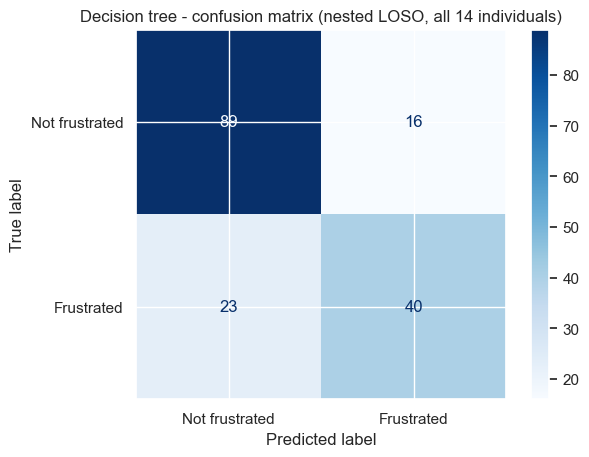

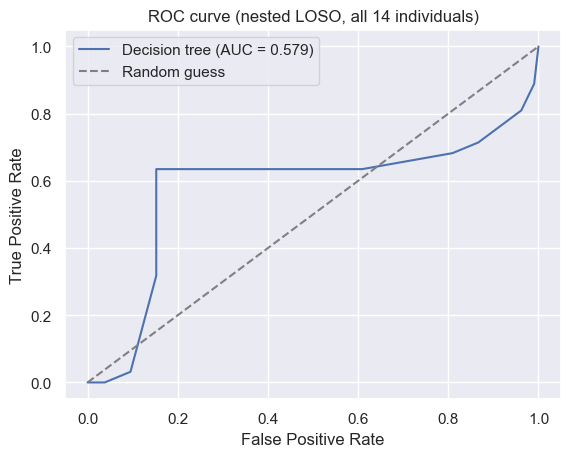

In [4]:
overall_accuracy = accuracy_score(oof_true, oof_pred)
overall_balanced_accuracy = balanced_accuracy_score(oof_true, oof_pred)
overall_auc = roc_auc_score(oof_true, oof_proba)

print(f"Nested LOSO accuracy:          {overall_accuracy:.3f}")
print(f"Nested LOSO balanced accuracy: {overall_balanced_accuracy:.3f}")
print(f"Nested LOSO ROC-AUC:           {overall_auc:.3f}\n")
print("Classification report (all 168 out-of-fold predictions):")
print(classification_report(oof_true, oof_pred, target_names=["Not frustrated", "Frustrated"], zero_division=0))

cm = confusion_matrix(oof_true, oof_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not frustrated", "Frustrated"])
disp.plot(cmap="Blues")
plt.title("Decision tree - confusion matrix (nested LOSO, all 14 individuals)")
plt.show()

fpr, tpr, _ = roc_curve(oof_true, oof_proba)
plt.plot(fpr, tpr, label=f"Decision tree (AUC = {overall_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (nested LOSO, all 14 individuals)")
plt.legend()
plt.show()

## Per-individual performance and `max_depth` stability

Because each outer fold corresponds to one individual, we get 14 separate accuracy scores and 14
selected `max_depth` values. This shows whether performance is consistent across individuals, and
whether the cross-validated `max_depth` is stable or varies a lot from fold to fold.

 Individual  best_max_depth  accuracy  balanced_accuracy
          3               1  0.166667           0.187500
         13               1  0.583333           0.318182
          6               1  0.666667           0.666667
          7               1  0.583333           0.722222
          4               1  0.750000           0.728571
          5               1  0.750000           0.785714
          9               1  0.833333           0.812500
         10               1  0.750000           0.863636
         14               1  0.916667           0.900000
          1               1  0.916667           0.944444
         11               1  0.916667           0.944444
         12               1  0.916667           0.944444
          2               1  1.000000           1.000000
          8               1  1.000000           1.000000

Mean per-individual accuracy:          0.768 ± 0.222
Mean per-individual balanced accuracy: 0.773 ± 0.245

Selected max_depth across folds:
best

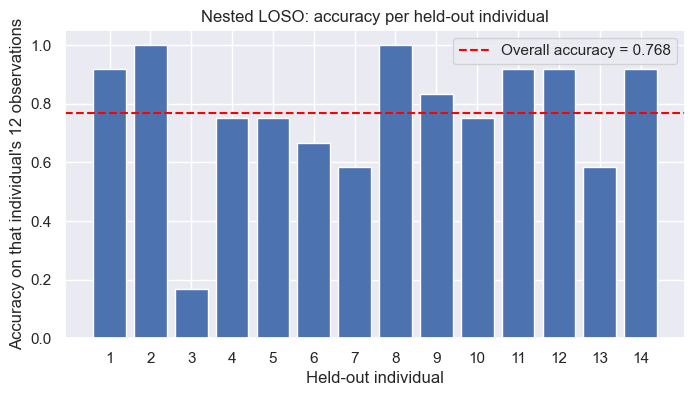

In [5]:
print(fold_df[["Individual", "best_max_depth", "accuracy", "balanced_accuracy"]]
      .sort_values("balanced_accuracy").to_string(index=False))

print(f"\nMean per-individual accuracy:          {fold_df['accuracy'].mean():.3f} ± {fold_df['accuracy'].std():.3f}")
print(f"Mean per-individual balanced accuracy: {fold_df['balanced_accuracy'].mean():.3f} ± {fold_df['balanced_accuracy'].std():.3f}")
print(f"\nSelected max_depth across folds:\n{fold_df['best_max_depth'].value_counts().sort_index()}")

plt.figure(figsize=(8, 4))
plt.bar(fold_df["Individual"].astype(str), fold_df["accuracy"])
plt.axhline(overall_accuracy, color="red", linestyle="--", label=f"Overall accuracy = {overall_accuracy:.3f}")
plt.xlabel("Held-out individual")
plt.ylabel("Accuracy on that individual's 12 observations")
plt.title("Nested LOSO: accuracy per held-out individual")
plt.legend()
plt.show()

## Final decision tree (fit on all individuals) for interpretation

The nested LOSO loop above gives an honest performance estimate, but it produced 14 different trees
(one per fold, each possibly with a different `max_depth`). To *interpret* the model (the tree
structure, decision regions), we select `max_depth` via the same `GridSearchCV` + `GroupKFold`
search on **all 14 individuals** and fit **one final tree on all the data**. This final tree is not
used for any performance claims — those come from the sections above.

Final max_depth: 1


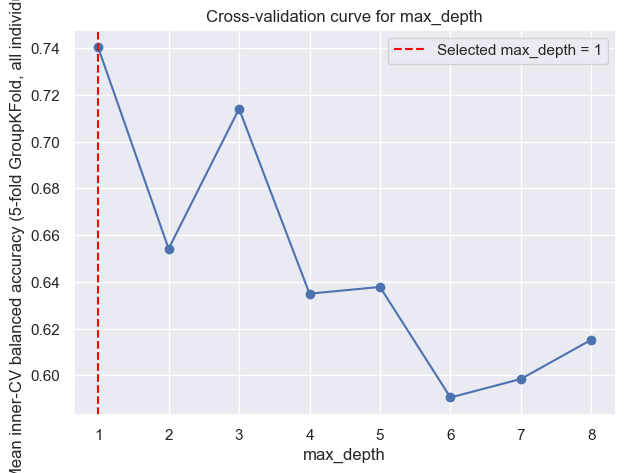

Final max_depth: 1
Actual depth of the tree: 1


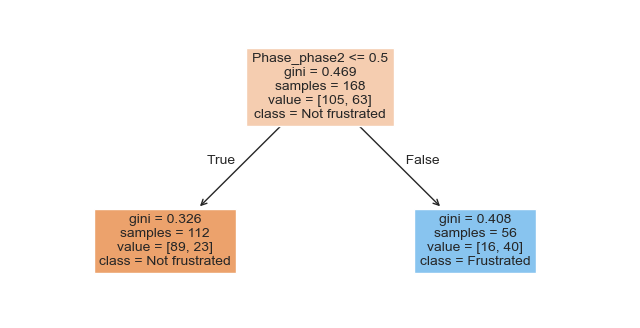

In [6]:
final_inner_cv = GroupKFold(n_splits=5)

final_grid_search = GridSearchCV(
    pipeline, param_grid, cv=final_inner_cv, scoring="balanced_accuracy", n_jobs=-1,
)
final_grid_search.fit(X_np, y_np, groups=groups)
final_model = final_grid_search.best_estimator_

final_max_depth = final_grid_search.best_params_["clf__max_depth"]
final_tree = final_model.named_steps["clf"]

print(f"Final max_depth: {final_max_depth}")

# Cross-validation curve: mean inner-CV balanced accuracy vs. max_depth
cv_results = pd.DataFrame(final_grid_search.cv_results_)

plt.figure(figsize=(7, 5))
plt.plot(cv_results["param_clf__max_depth"], cv_results["mean_test_score"], marker="o")
plt.axvline(final_max_depth, color="red", linestyle="--", label=f"Selected max_depth = {final_max_depth}")
plt.xlabel("max_depth")
plt.ylabel("Mean inner-CV balanced accuracy (5-fold GroupKFold, all individuals)")
plt.title("Cross-validation curve for max_depth")
plt.legend()
plt.show()

# Figure size scales with the number of leaves/depth, capped so very deep trees stay renderable
n_leaves = final_tree.get_n_leaves()
fig_width = min(max(8, 2 * n_leaves), 40)
fig_height = min(max(4, 3 * final_tree.get_depth()), 20)
fig = plt.figure(figsize=(fig_width, fig_height), dpi=100)
_ = plot_tree(final_tree, feature_names=feature_cols, class_names=["Not frustrated", "Frustrated"], filled=True, fontsize=10)
print(f"Final max_depth: {final_max_depth}")
print(f"Actual depth of the tree: {final_tree.get_depth()}")
plt.show()

## Visualizing the data and decision regions (PCA)

`X` has 10 features (5 HR features plus one-hot encoded `Phase`/`Round`), which is too many to plot
directly. We use PCA to project the (standardized) features onto their first 2 principal
components and plot:

1. The data points colored by `Frustrated_binary`.
2. The decision regions of a decision tree (same `max_depth` as the final model above) **re-fit on
   the 2D PCA projection**, purely to visualize how a tree of this depth partitions the space. Note
   that this is a different model than `final_tree` (which splits on the original features) — it's
   an illustrative approximation in 2D.


Explained variance ratio: [0.33026396 0.15627432]
Total variance explained by 2 components: 48.65%


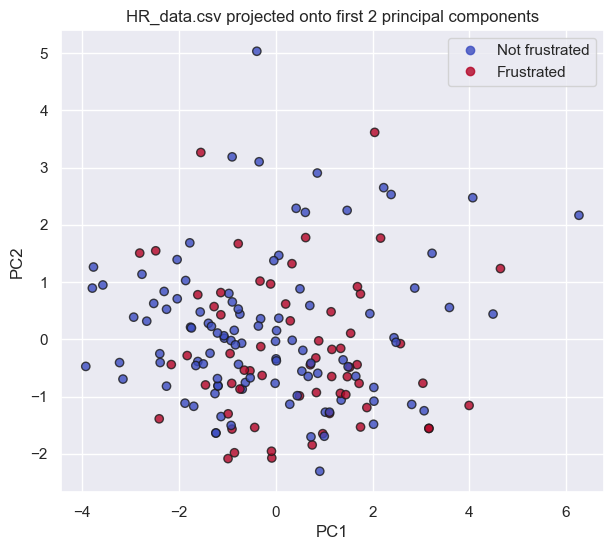

In [7]:
# Standardize before PCA (HR features and one-hot columns are on different scales)
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_np)

pca = PCA(n_components=2, random_state=seed)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_np, cmap="coolwarm", edgecolor="k", alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("HR_data.csv projected onto first 2 principal components")
plt.legend(handles=scatter.legend_elements()[0], labels=["Not frustrated", "Frustrated"])
plt.show()


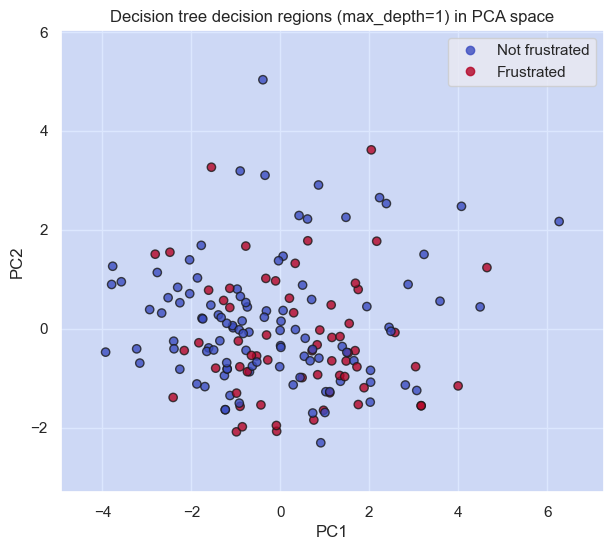

In [8]:
# Re-fit a decision tree (same final_max_depth) directly on the 2D PCA projection, for visualization
tree_pca = DecisionTreeClassifier(criterion="gini", max_depth=final_max_depth, random_state=seed)
tree_pca.fit(X_pca, y_np)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = tree_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_np, cmap="coolwarm", edgecolor="k", alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Decision tree decision regions (max_depth={final_max_depth}) in PCA space")
plt.legend(handles=scatter.legend_elements()[0], labels=["Not frustrated", "Frustrated"])
plt.show()


## 12. Save out-of-fold results for model comparison

We save the pooled nested-LOSO out-of-fold predictions (`oof_true`, `oof_pred`, `oof_proba`) and the
per-individual fold metrics, so they can be compared against the other two models in
`model_comparison.ipynb`.

In [9]:
np.savez(
    "results_tree.npz",
    model_name="Decision Tree",
    oof_true=oof_true,
    oof_pred=oof_pred,
    oof_proba=oof_proba,
    fold_individual=fold_df["Individual"].to_numpy(),
    fold_accuracy=fold_df["accuracy"].to_numpy(),
    fold_balanced_accuracy=fold_df["balanced_accuracy"].to_numpy(),
)
print("Saved nested-LOSO results to results_tree.npz")

Saved nested-LOSO results to results_tree.npz
